# Topic: Analyzing the Dark Matter Halo Shape of M33 

### Question: How does the ellipticity of M33's DM halo shape change over time in a face-on projection

### Output Plots: Ellipticity versus time of M33's halo taken at R500, R500/2, and R500/4, DM particle density projections 

### Code outline:

1. Loop over every 10 snapshots over full snapshot range
2. Record time, ellipticity, position angle, semimajor axis, and semiminor axis information at the R500, R500/2, and R500/4 distances
3. Save to a table as a row and save full table to txt file
4. Read in txt file to plot ellipticity versus time at each of these distances

In [1]:
# Nicolas Mazziotti

# import modules
import numpy as np
import astropy.units as u
from astropy.constants import G

# import plotting modules
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tqdm import tqdm

# my modules
from ReadFile import Read
from CenterOfMass import CenterOfMass
from MassProfile import MassProfile
from HaloShape import HaloShape

# for ellipse fitting 
from photutils.isophote import Ellipse, EllipseGeometry

In [68]:
# Directory on nimoy where the high resolution data files are stored
HighResDir = '../../../../astr400b/HighRes/'

# Create Projections At Every 10 Snapshots

In [3]:
# No lists; use arrays, or list comprehension

In [4]:
# Define snapshot range from 0 to 799, using every 10 snaps
snap_range = np.arange(0, 799, 10)

/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/_methods.py:262: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/nmazziotti/.local/lib/python3.8/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
 64%|███████████████████████████▍               | 51/80 [07:59<04:32,  9.40

OverflowError: cannot convert float infinity to integer

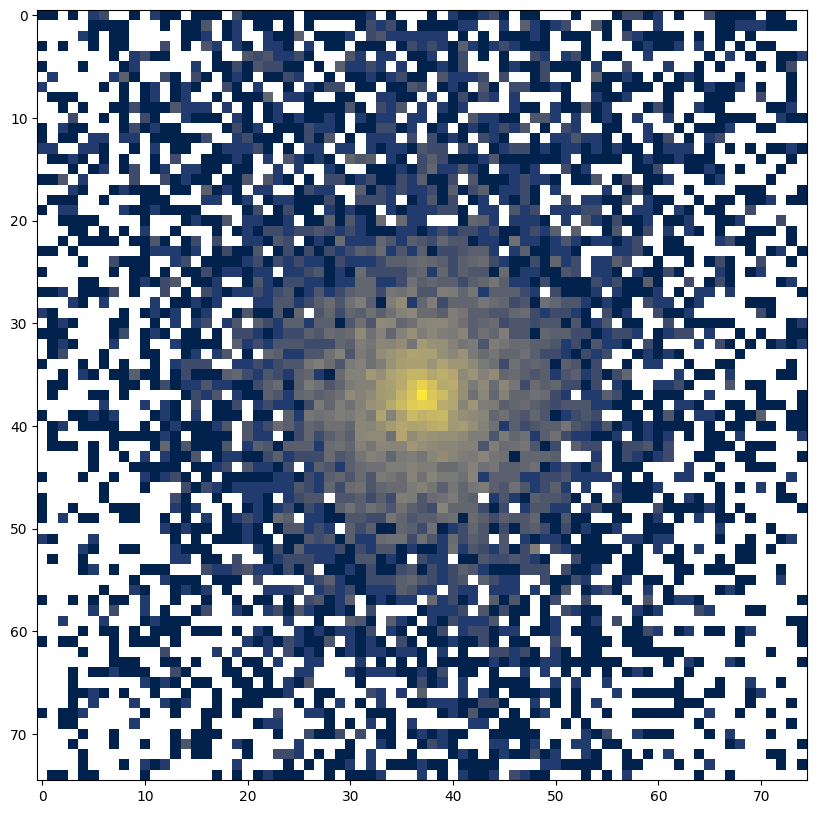

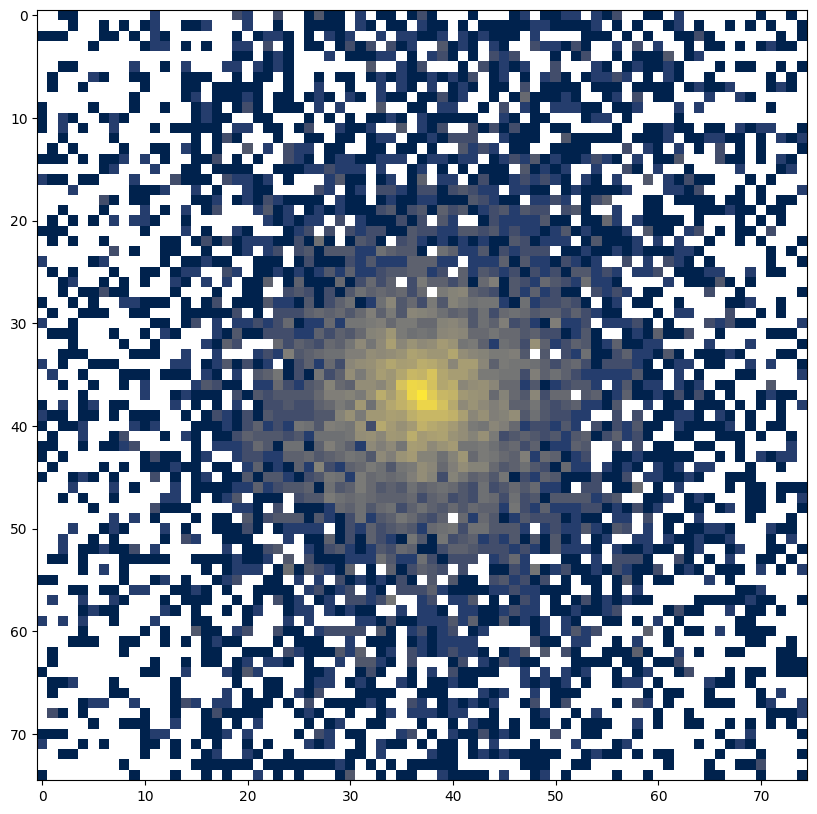

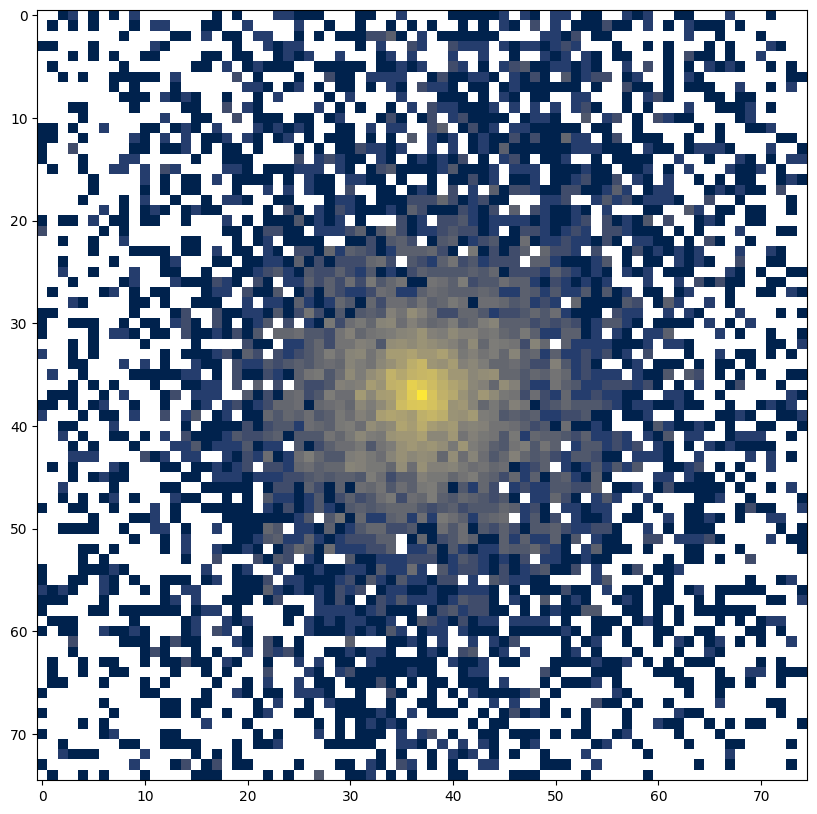

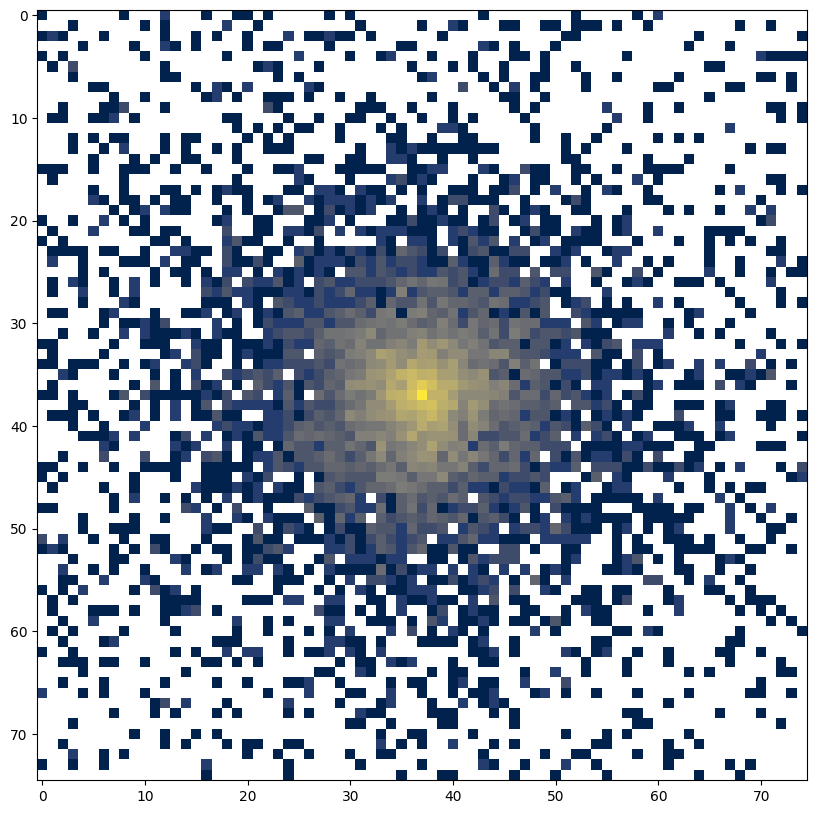

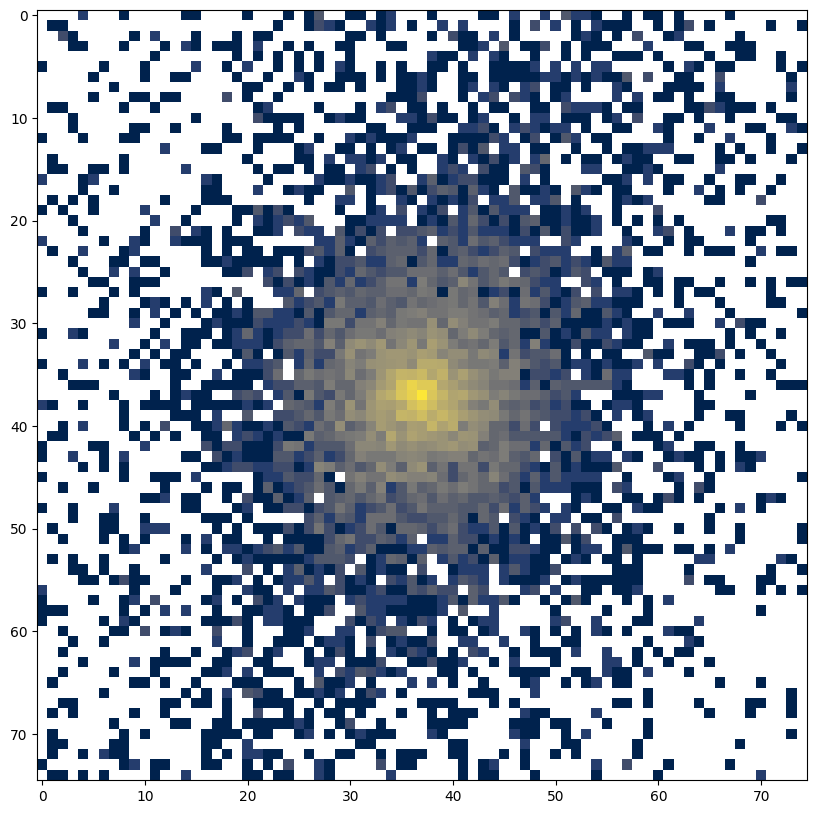

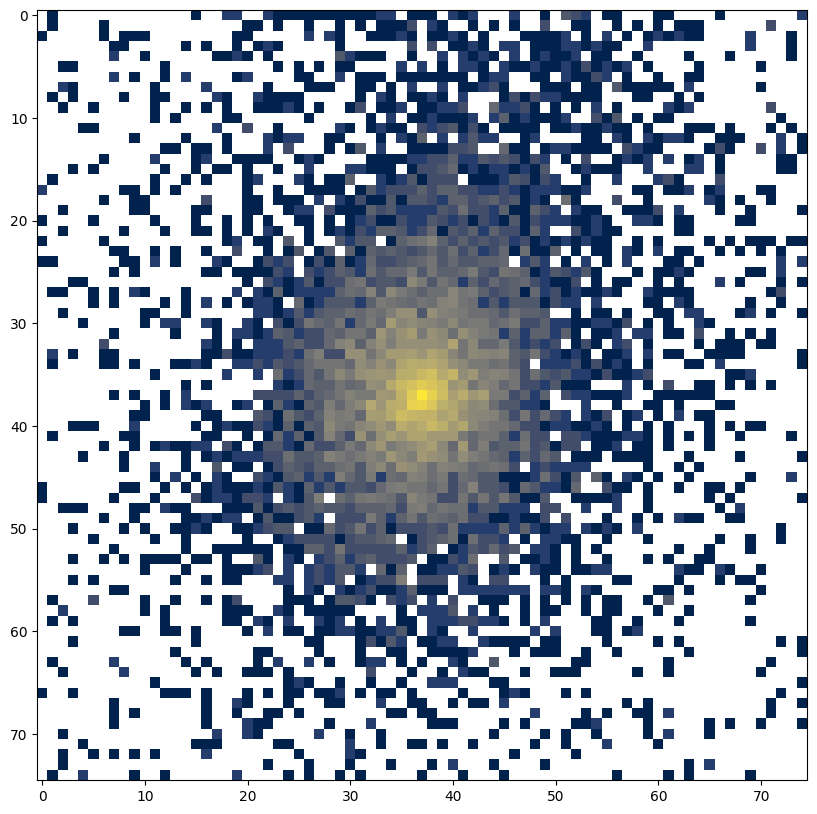

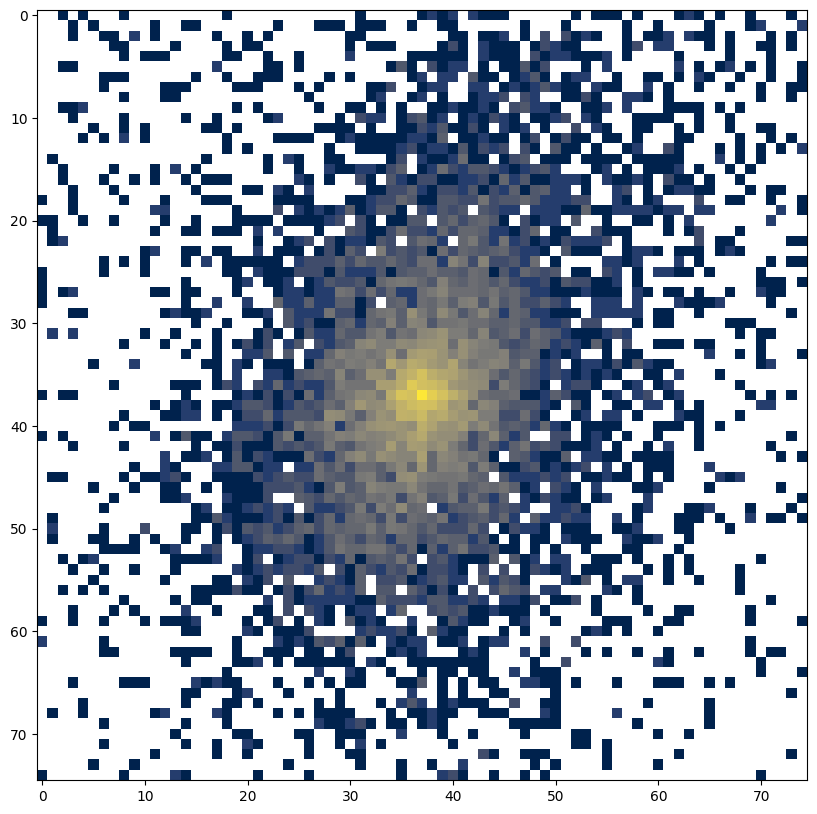

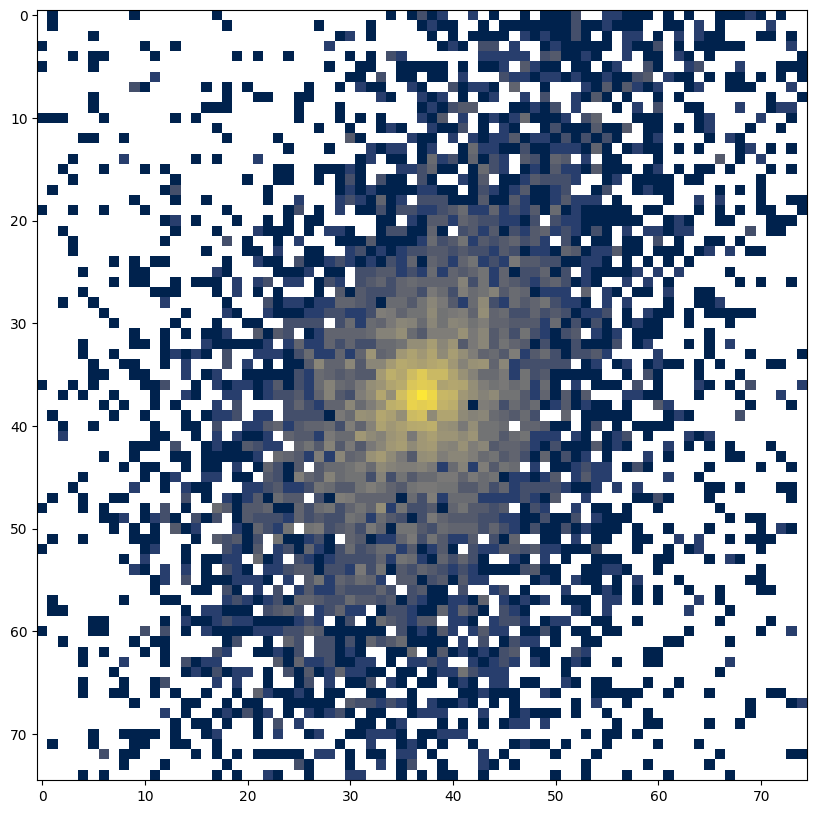

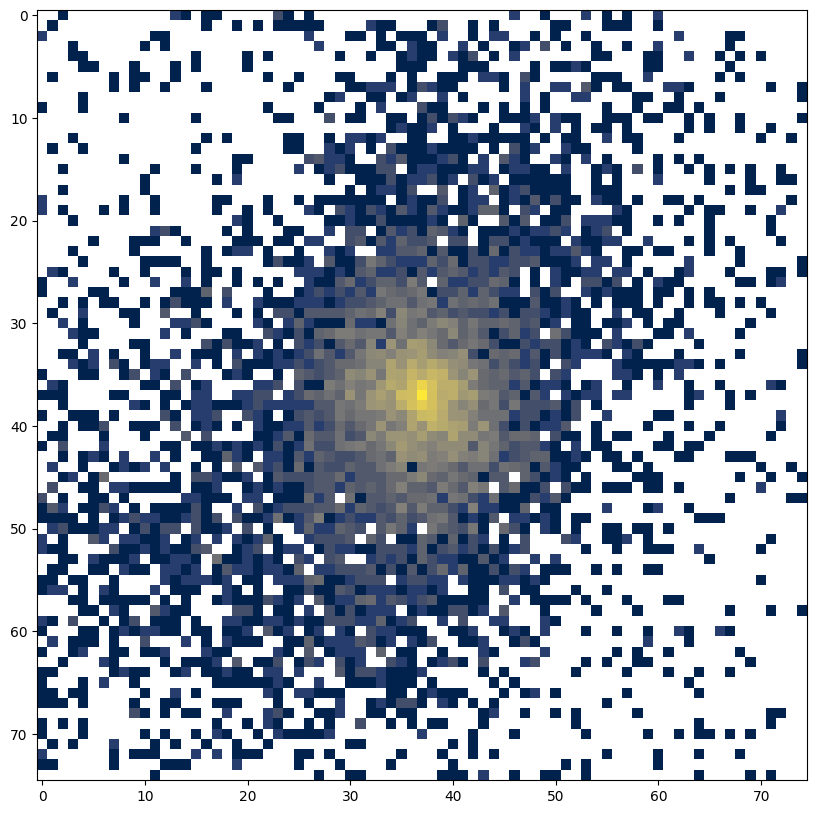

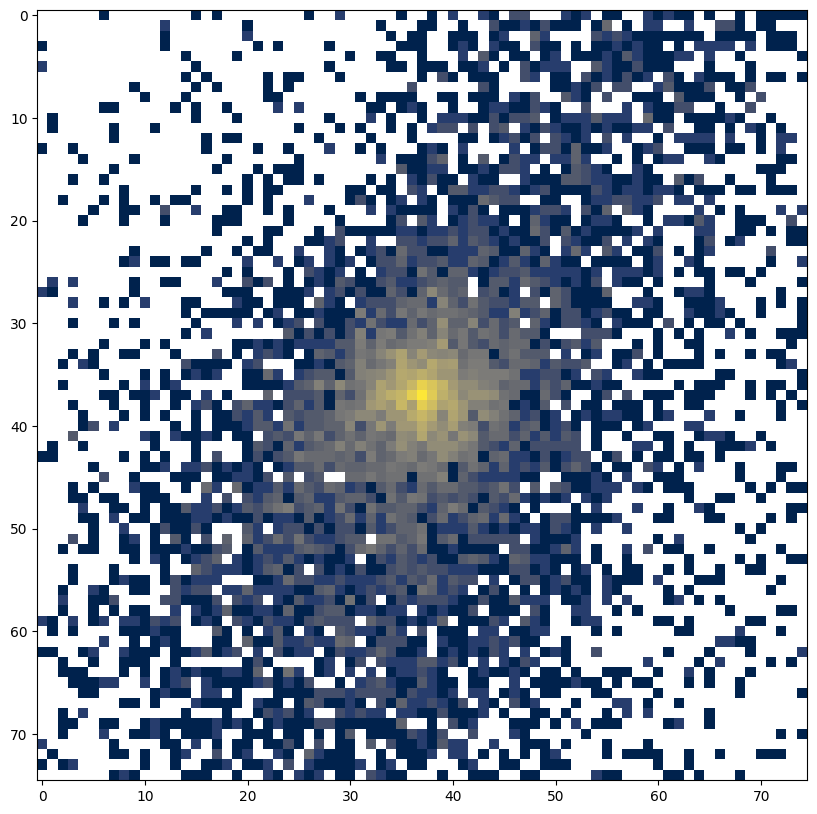

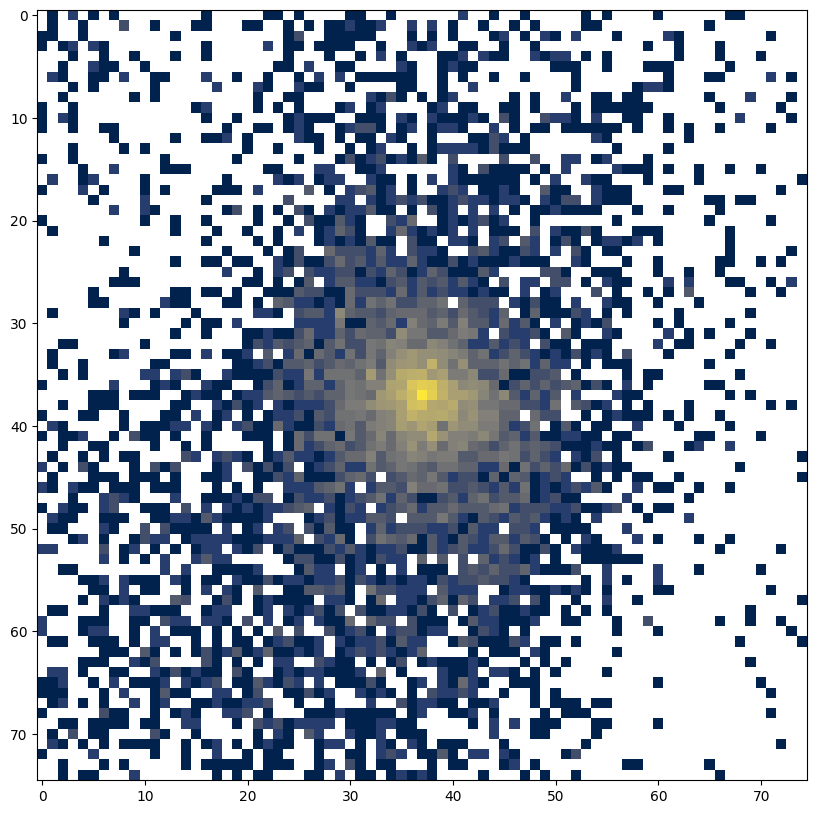

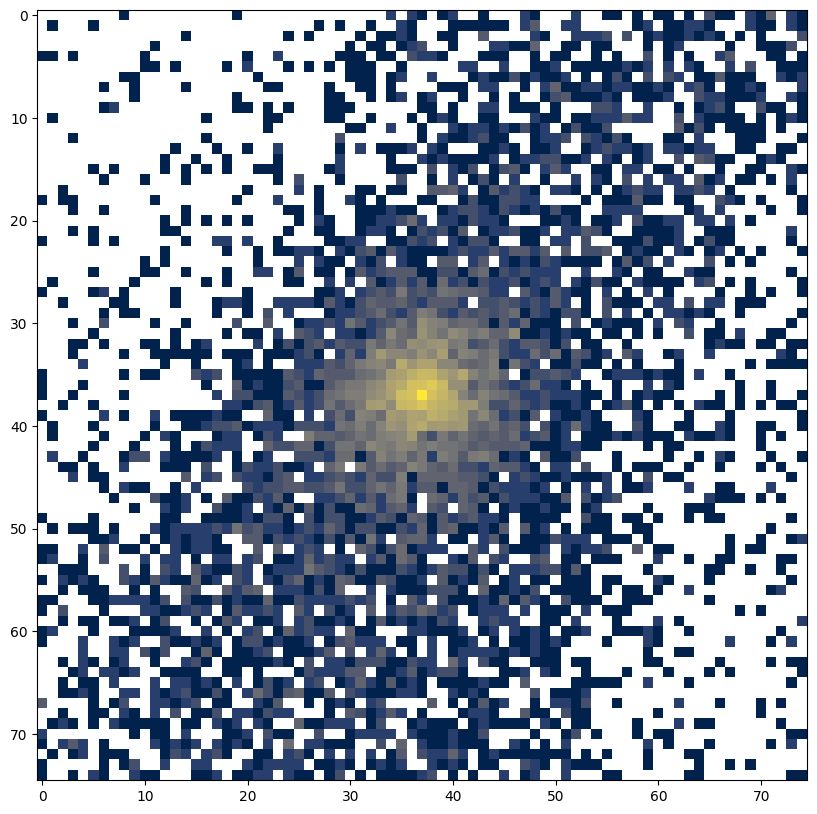

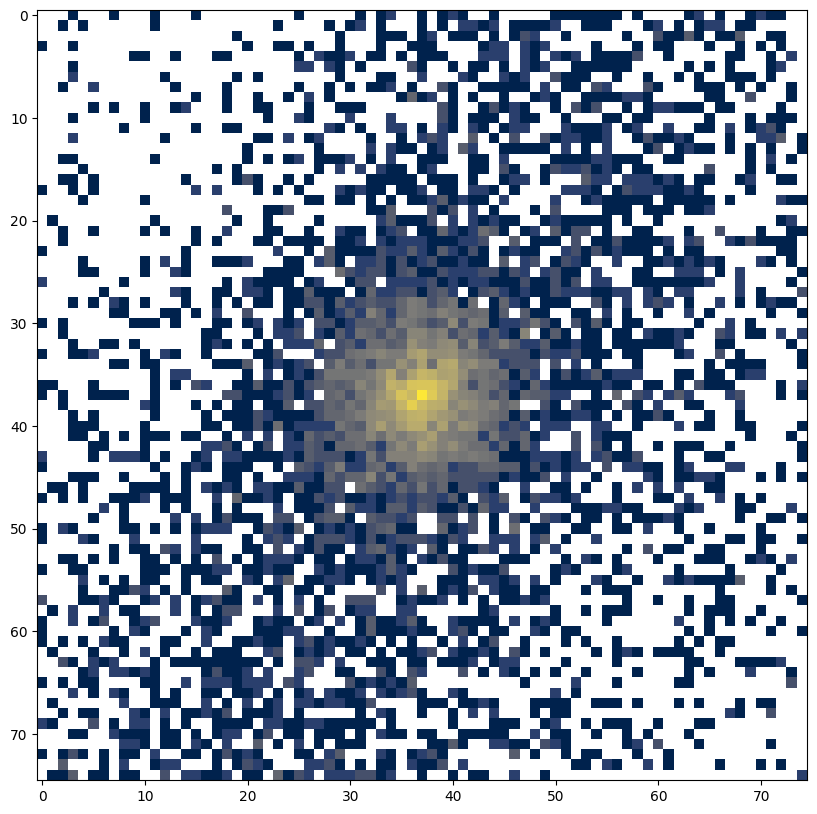

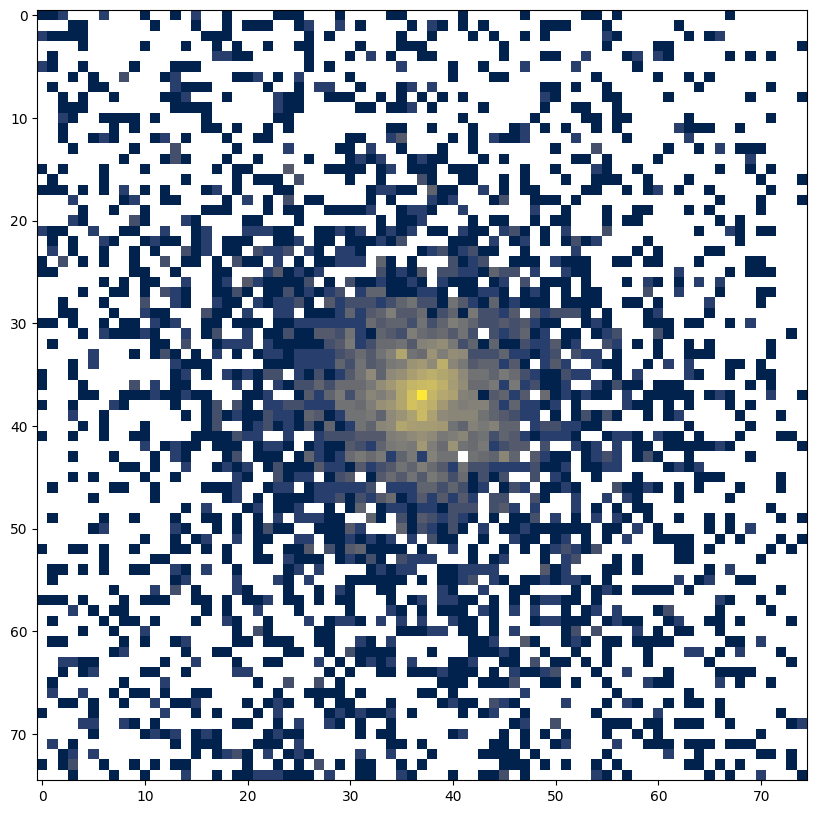

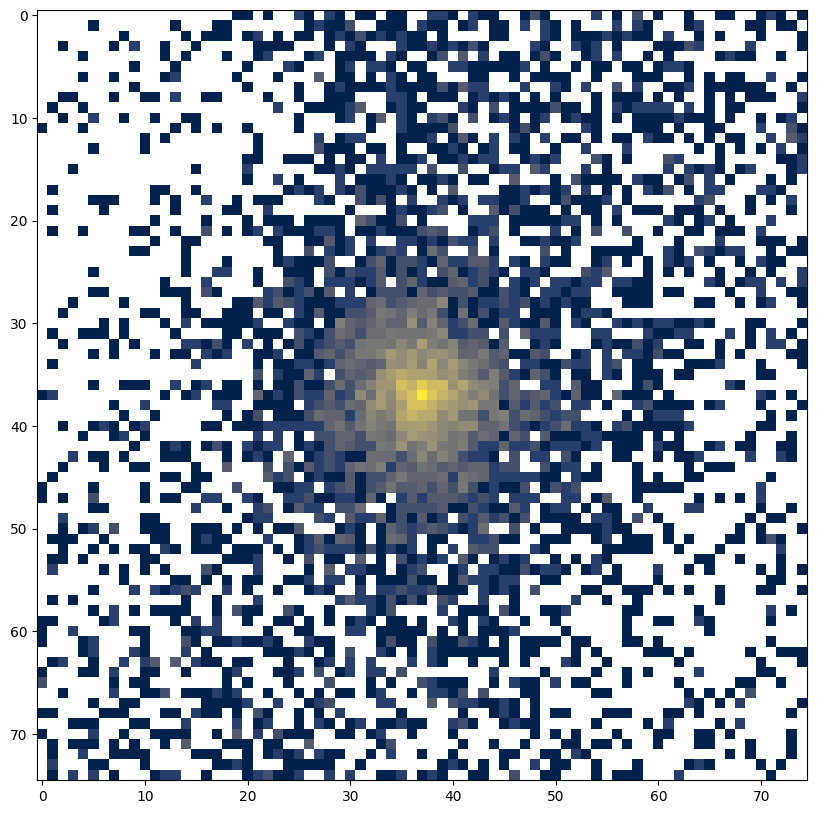

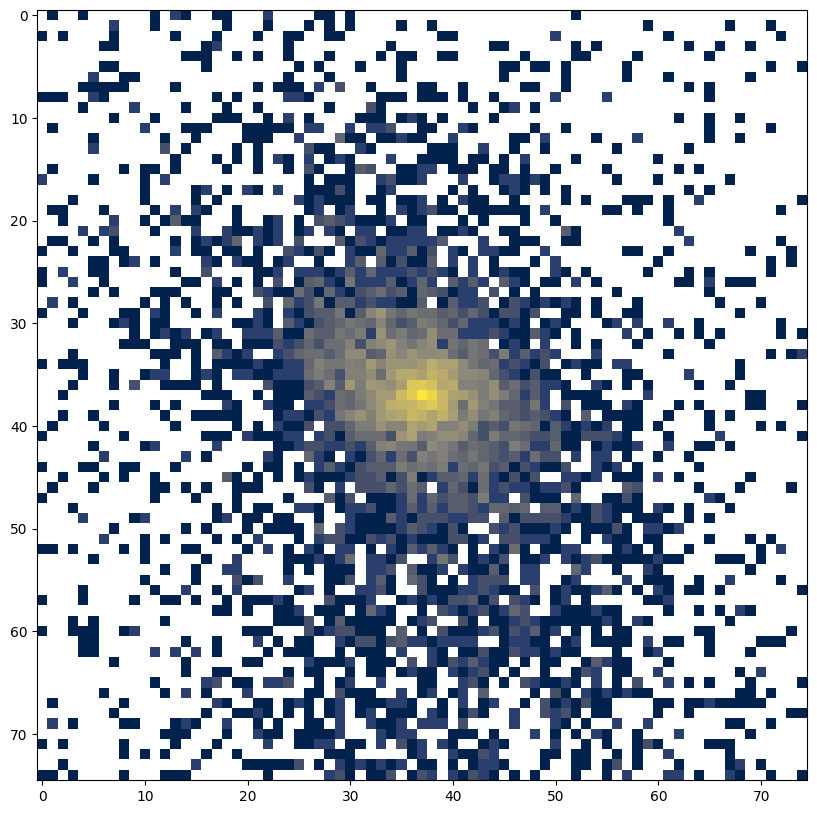

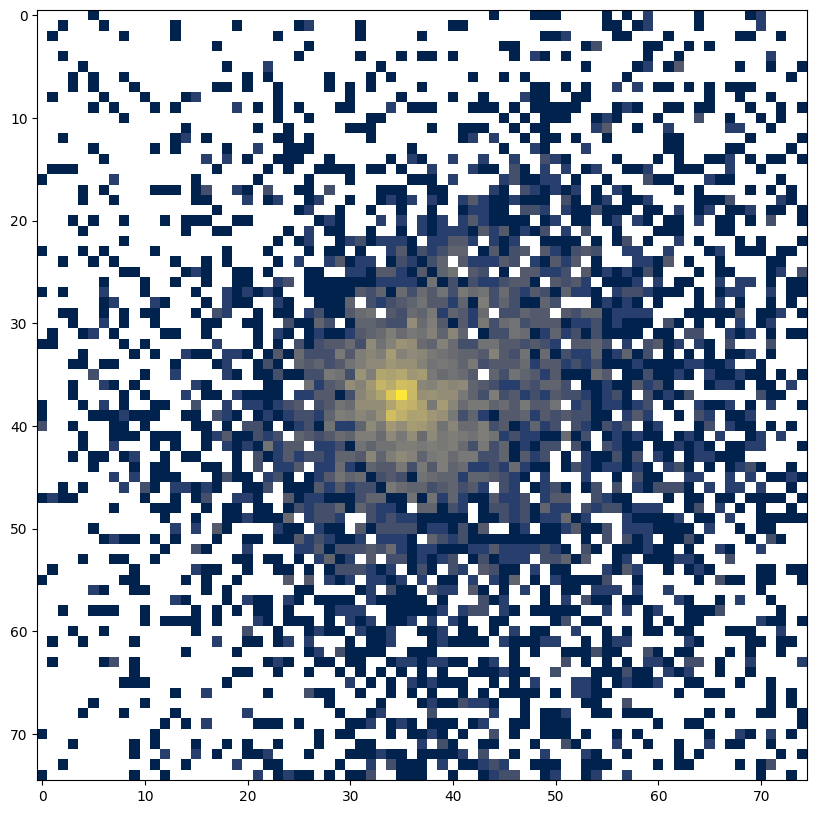

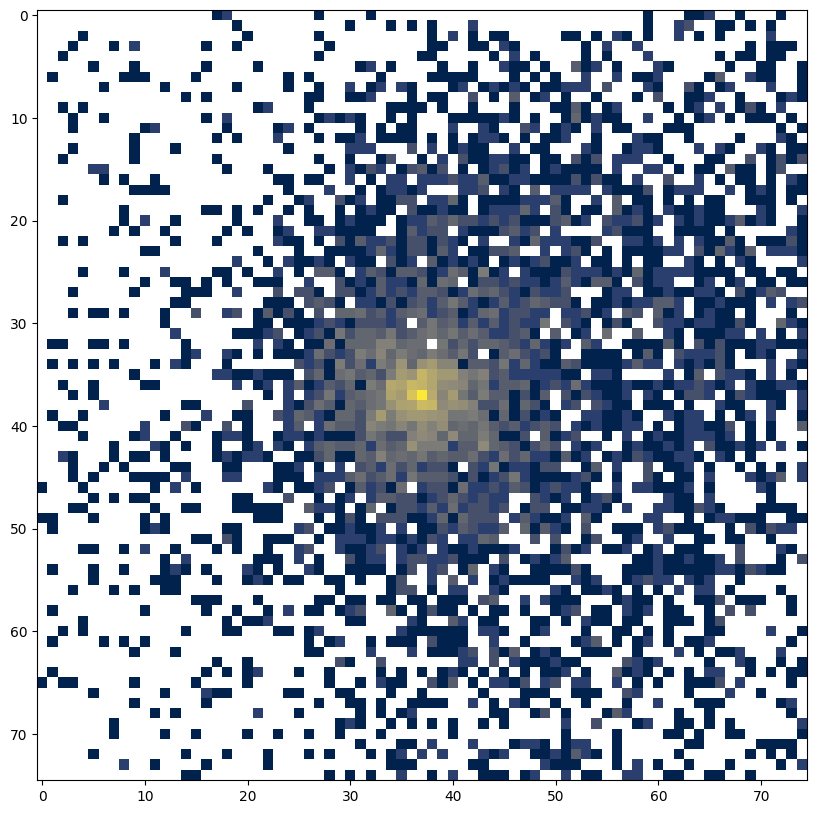

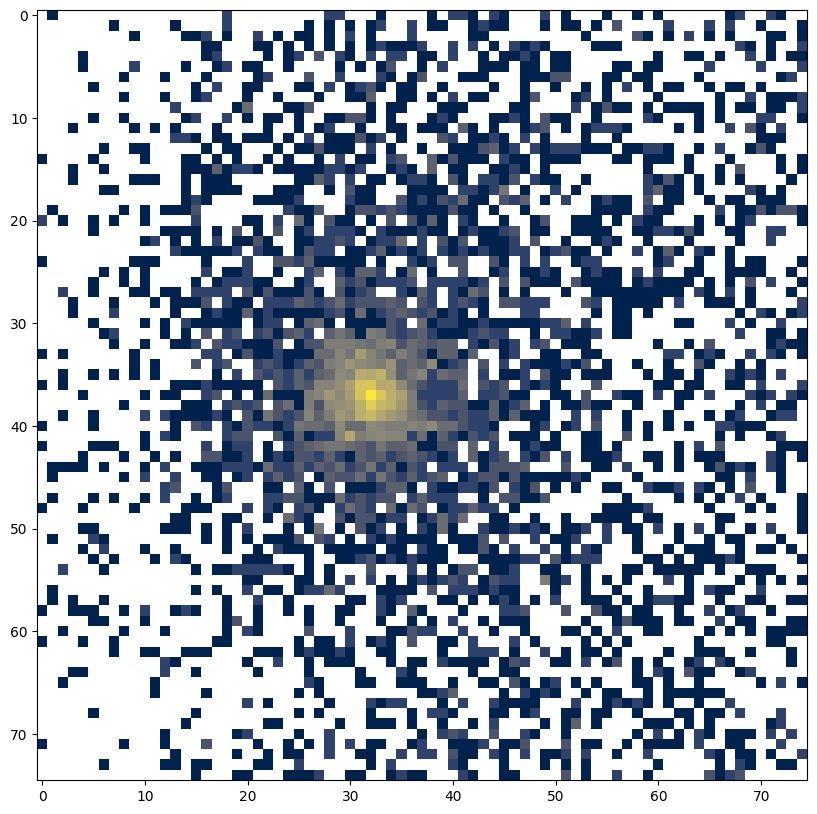

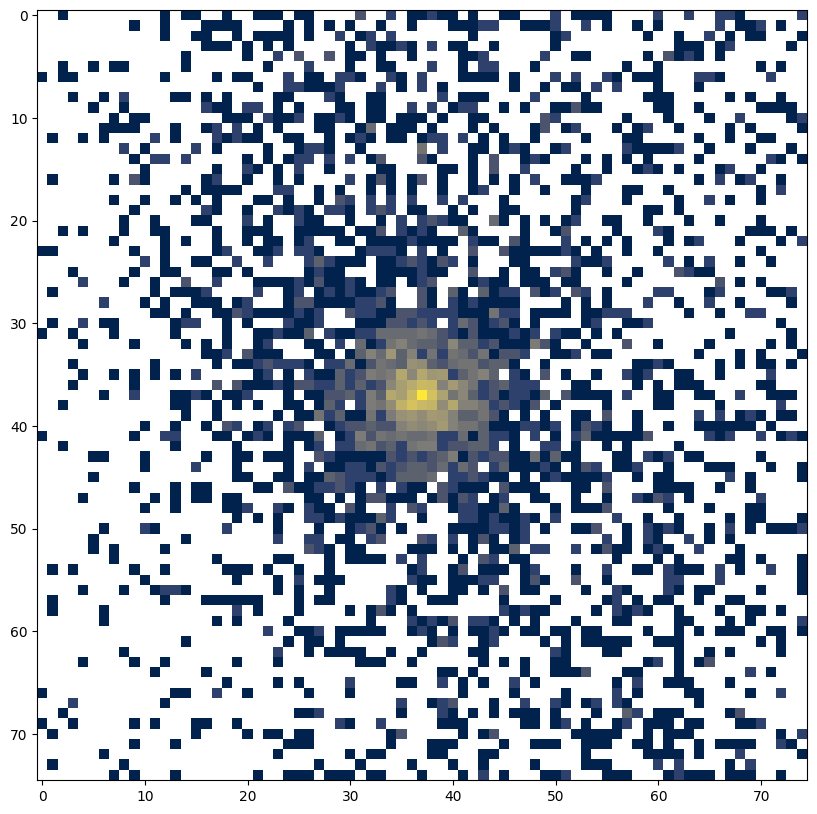

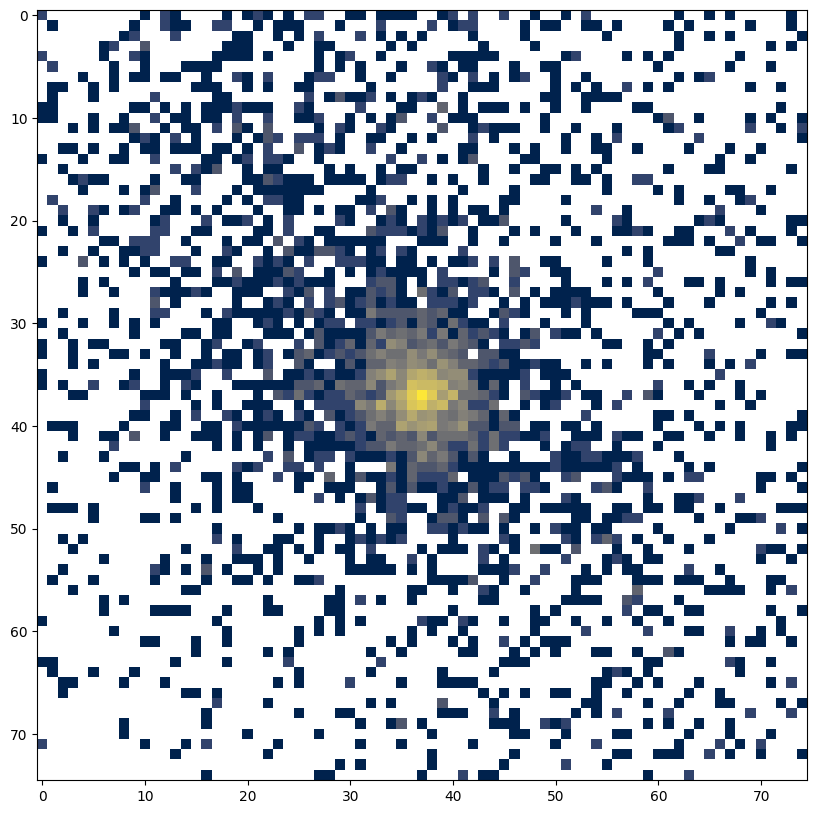

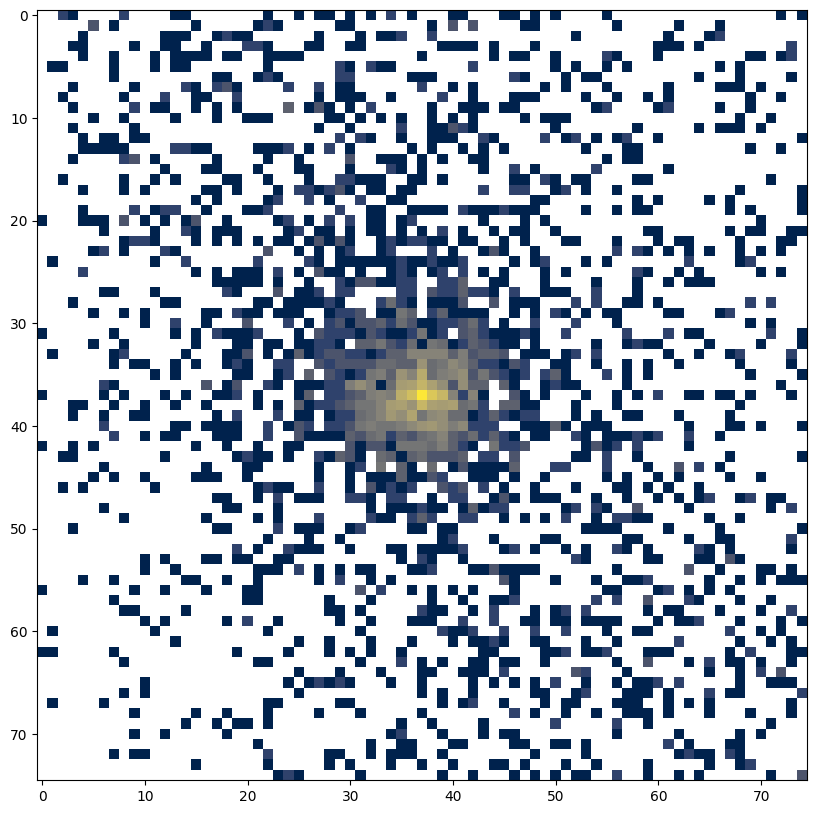

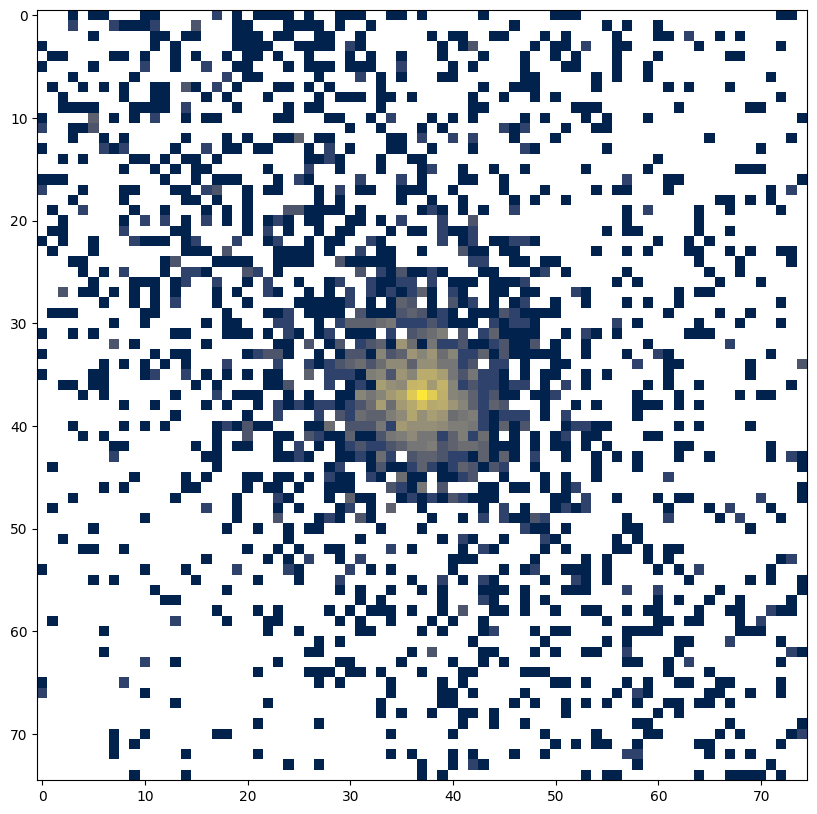

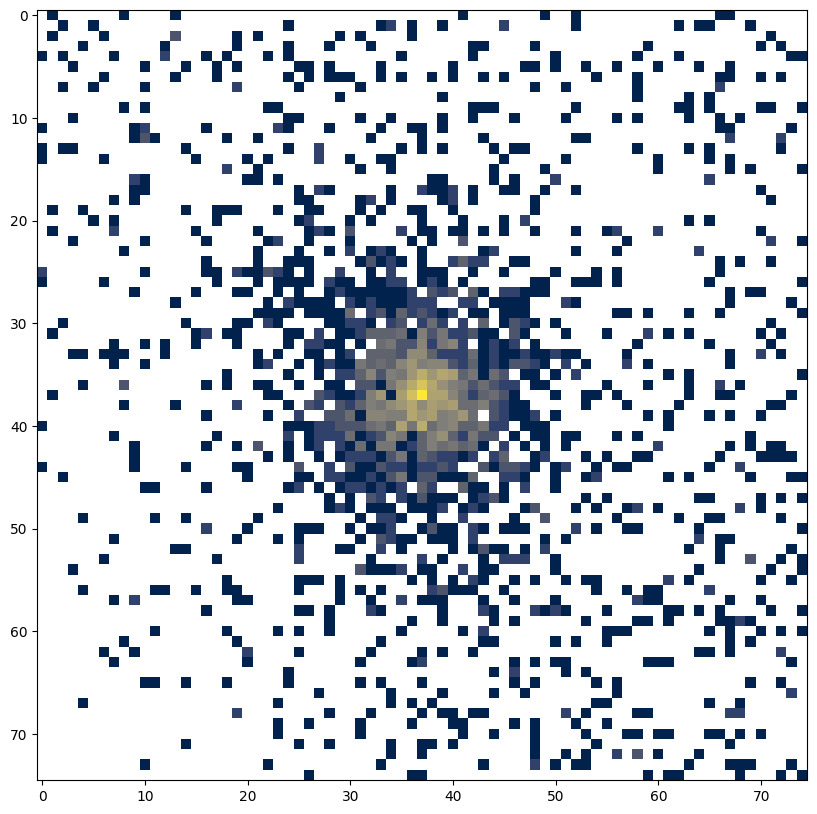

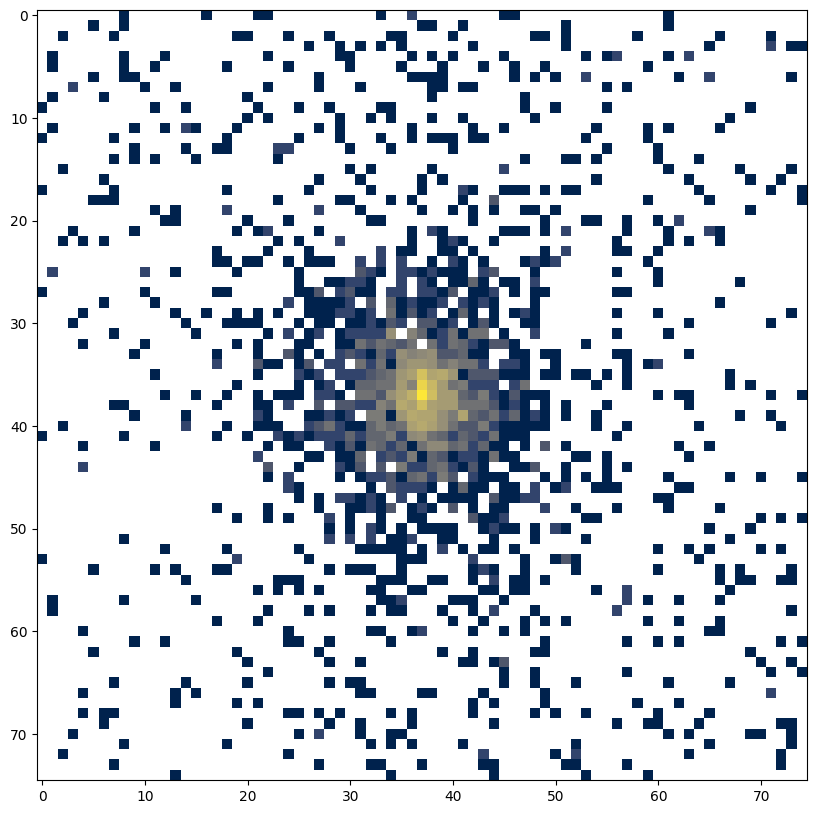

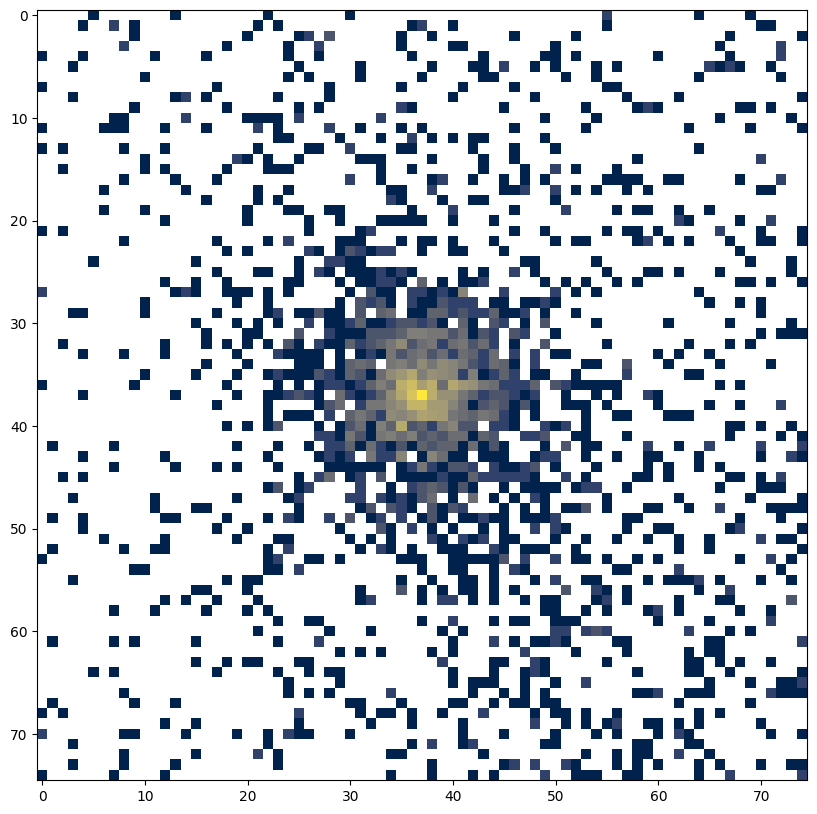

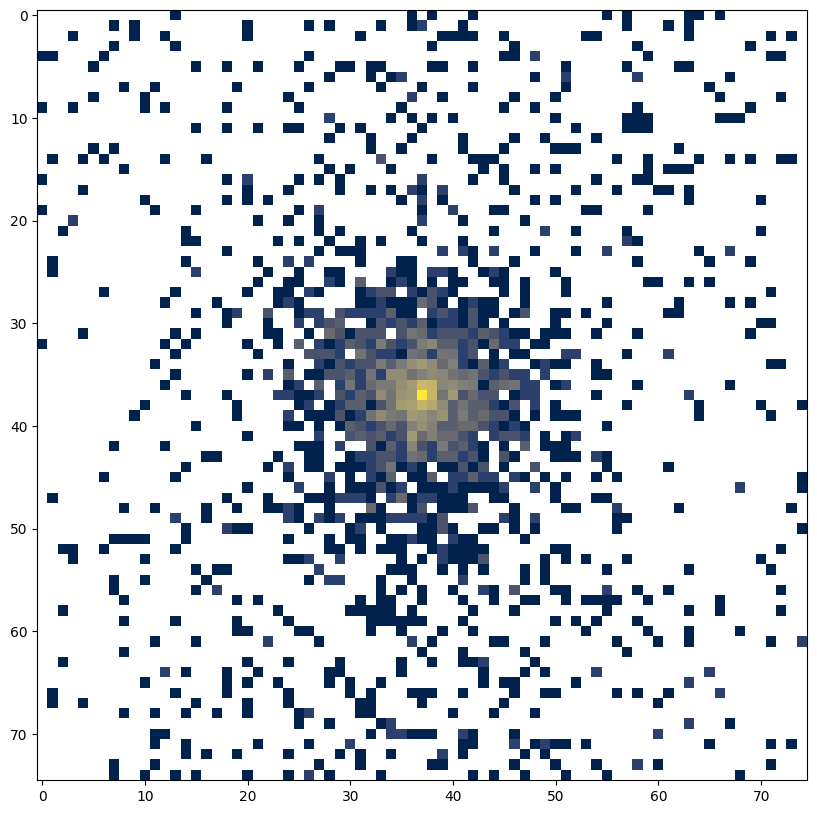

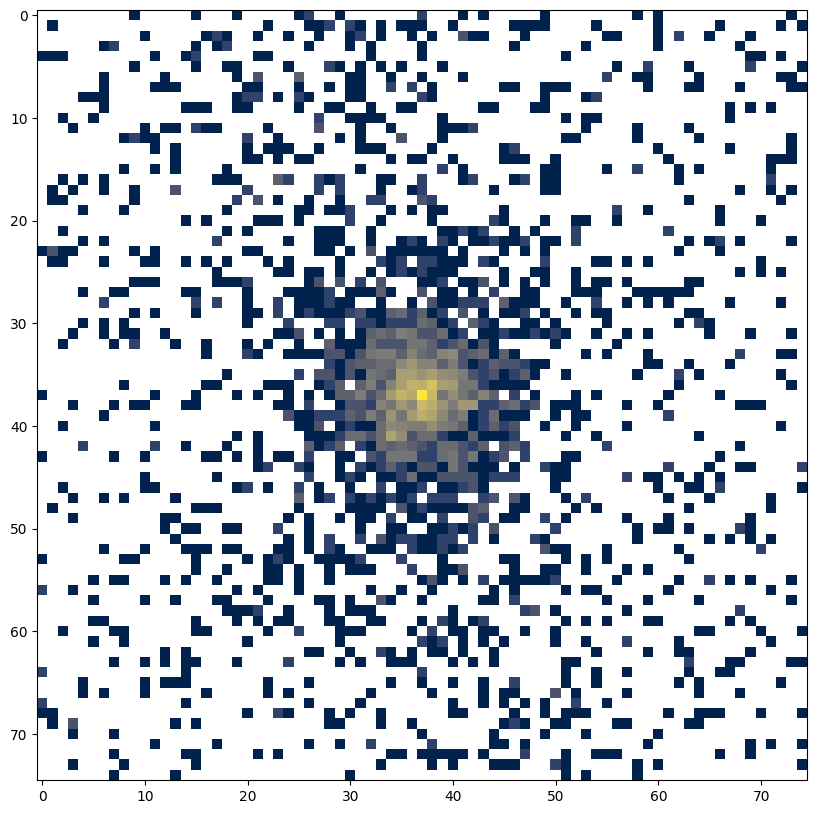

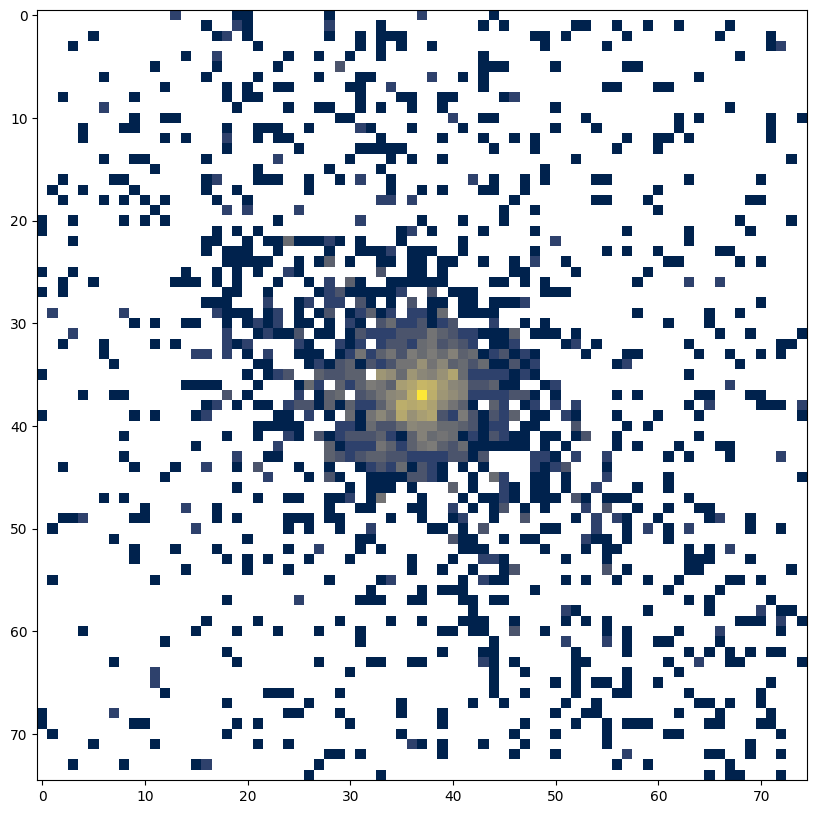

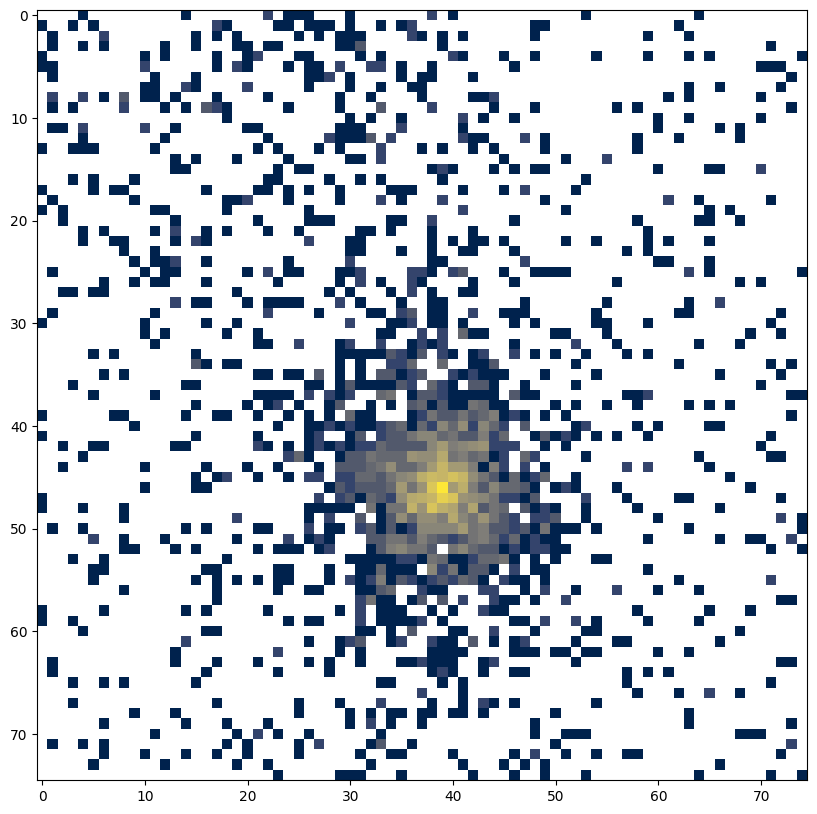

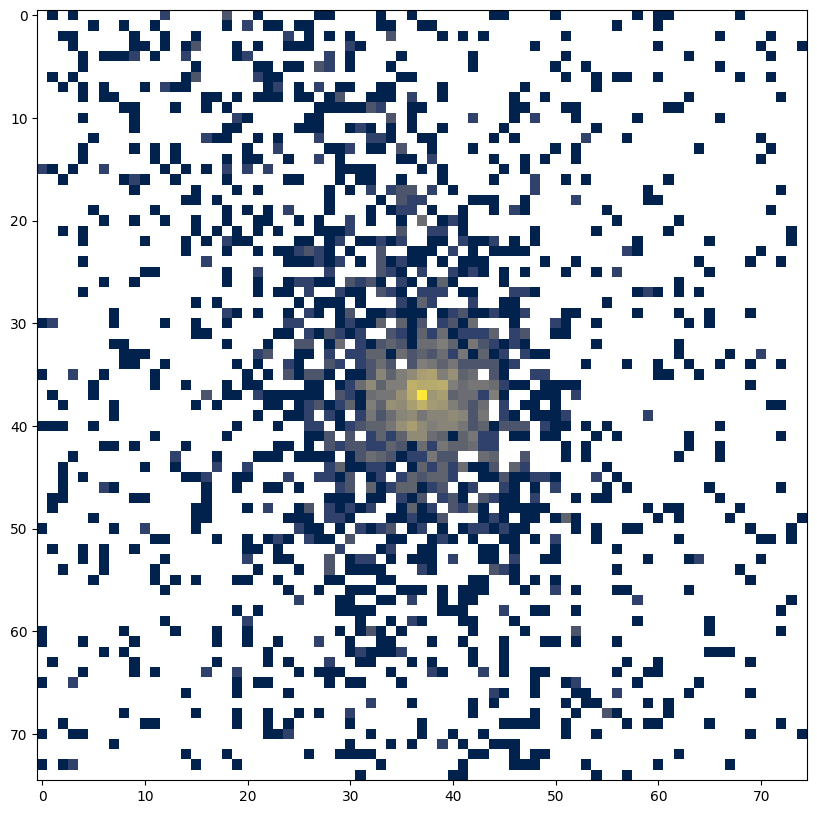

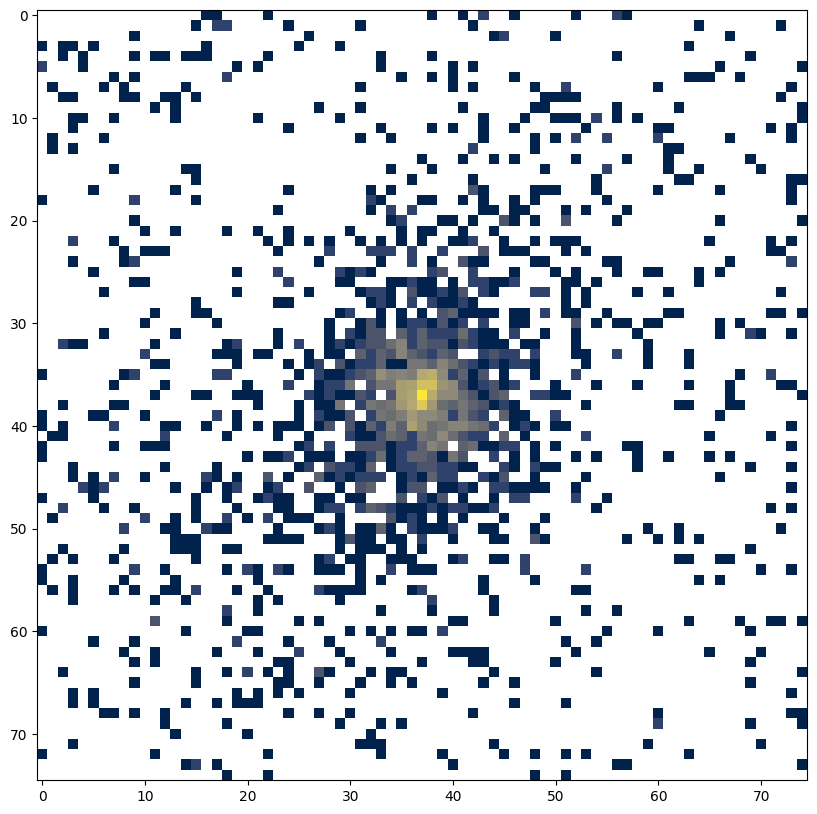

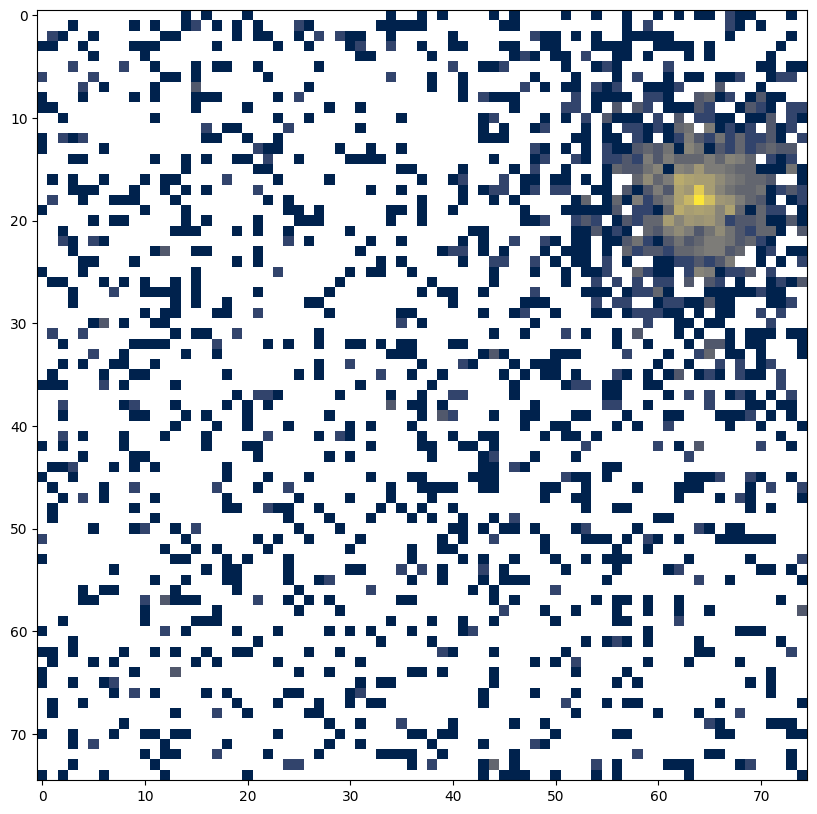

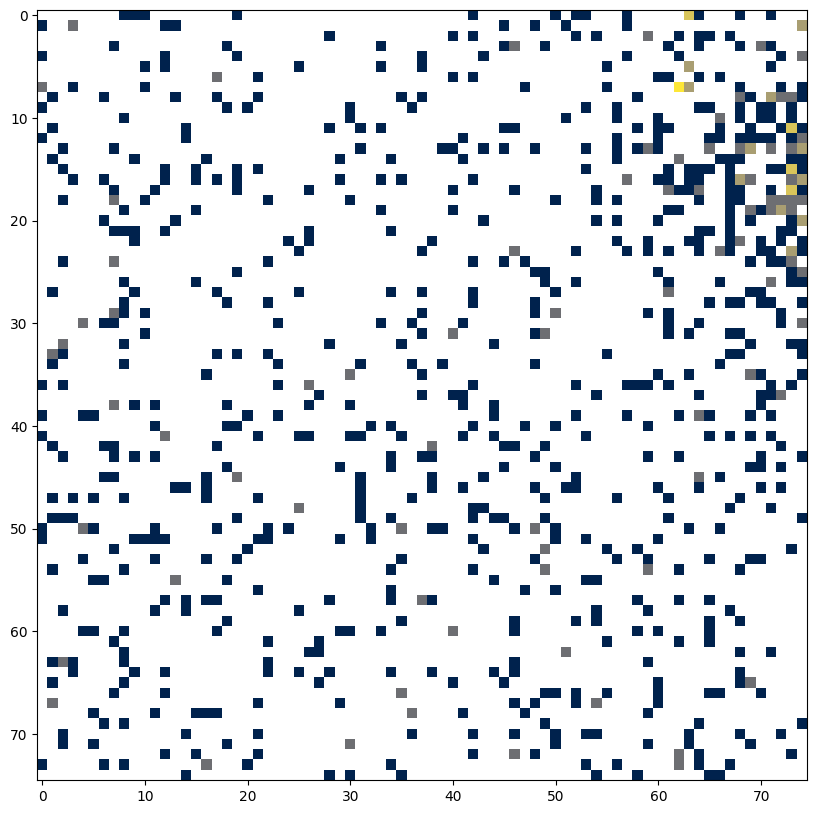

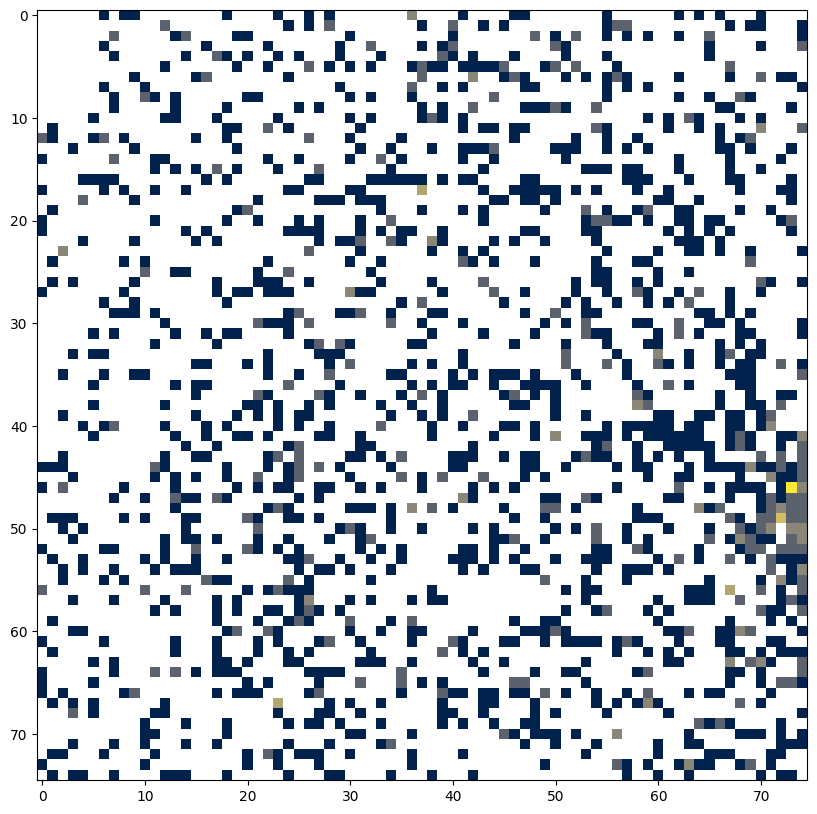

In [12]:
failed_snaps = [] # Sometimes the ellipse fitting fails, so store these snaps in this list
table_info = [] # Append rows of ellipse information to this list to create table from later on

# Looping through every 10 snapshots (tqdm to see progress)
for snap in tqdm(snap_range):
    # Create HaloShape object at given snap (see HaloShape.py)
    M33 = HaloShape('M33', snap)

    # See if ellipse fitting works for face-on projection of M33 
    try:
        # Retrieve fitting of all ellipses, and then the ellipticity, position angle, semimajor axis (a) in kpc, and semiminor axis (b)
        # in kpc at R500, R500/2, and R500/4
        isophotes, eps, pa, sma, smb = M33.PlotEllipses(0, 2) # (0 means x axis, 1 means y axis)

        # Save the snapshot time (Myr), and the ellipse information at R500, R500/2, and R500/4 to a row for our table
        row = M33.time.value, *tuple(eps), *tuple(pa), *tuple(sma), *tuple(smb)

        # Append row to table
        table_info.append(row)

    # If the ellipse fitting fails it will raise a ValueError
    except ValueError:
        # Try again but with smaller initial semimajor axis guess of 5 pixels (default is 10 pixels)
        try:
            isophotes, eps, pa, sma, smb = M33.PlotEllipses(0, 1, sma=5)
            row = M33.time.value, *tuple(eps), *tuple(pa), *tuple(sma), *tuple(smb)
            table_info.append(row)

        # If fails again, append snapshot to failed_snaps to see which snaps it failed at 
        except ValueError:  
            failed_snaps.append(snap)

In [33]:
failed_snaps

[220, 310, 320, 350, 410, 420, 440, 450, 470, 490, 500]

### Note: At each snapshot, the actual ellipses plotted on top of the projection are saved to the directory /plots/01/projections/. This is my other plot, which I will use later on to make a GIF. The radial profile of the fitted ellipses are similarly saved to /plots/01/ellipses/.

In [13]:
# Convert table information into a numpy array 
table_data = np.array(table_info)

# Save table to txt file 
np.savetxt('halo_evo_02.txt', table_data, fmt = "%11.3f"*13, comments='#',
               header="{:>10s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}"\
                      .format('t', 'r500_eps', 'r500/2_eps', 'r500/4_eps', 
                              'r500_pa', 'r500/2_pa', 'r500/4_pa',
                             'r500_sma', 'r500/2_sma', 'r500/4_sma',
                             'r500_smb', 'r500/2_smb', 'r500/4_smb'))

In [14]:
# Read in table information for the face-on projection (denoted 01)
Halo_01 = np.genfromtxt('halo_evo_01.txt')
Halo_12 = np.genfromtxt('halo_evo_12.txt')
Halo_02 = np.genfromtxt('halo_evo_02.txt')

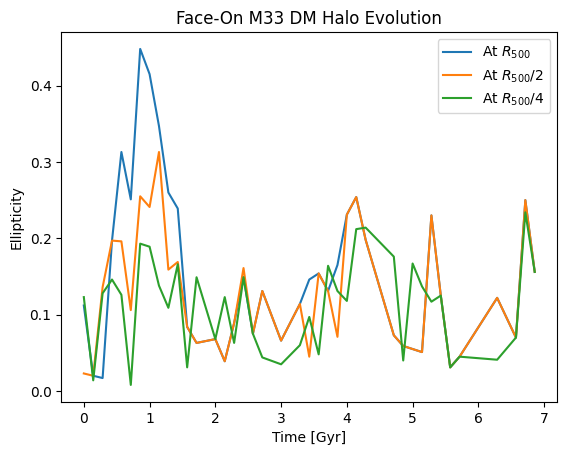

In [43]:
# Plot ellipticity for R500, R500/2, and R500/4 over time
plt.plot(Halo_01[:,0]/1000, Halo_01[:,1], label=r'At $R_{500}$')
plt.plot(Halo_01[:,0]/1000, Halo_01[:,2], label=r'At $R_{500}/2$')
plt.plot(Halo_01[:,0]/1000, Halo_01[:,3], label=r'At $R_{500}/4$')

plt.xlabel('Time [Gyr]')
plt.ylabel('Ellipticity')

plt.title('Face-On M33 DM Halo Evolution')

plt.legend()

plt.savefig('Ellipticity_Evolution_01.png')

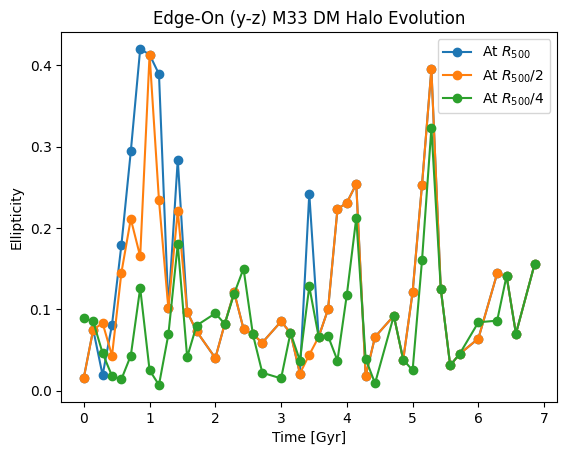

In [11]:
# Plot ellipticity for R500, R500/2, and R500/4 over time
plt.plot(Halo_12[:,0]/1000, Halo_12[:,1], label=r'At $R_{500}$', marker='o')
plt.plot(Halo_12[:,0]/1000, Halo_12[:,2], label=r'At $R_{500}/2$', marker='o')
plt.plot(Halo_12[:,0]/1000, Halo_12[:,3], label=r'At $R_{500}/4$', marker='o')

plt.xlabel('Time [Gyr]')
plt.ylabel('Ellipticity')

plt.title('Edge-On (y-z) M33 DM Halo Evolution')

plt.legend()

plt.savefig('Ellipticity_Evolution_12.png')

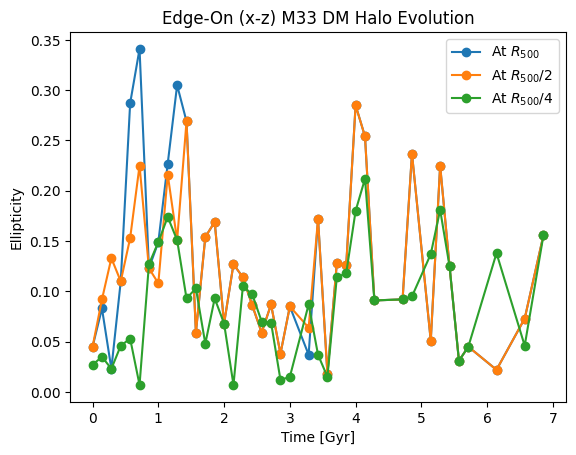

In [16]:
# Plot ellipticity for R500, R500/2, and R500/4 over time
plt.plot(Halo_02[:,0]/1000, Halo_02[:,1], label=r'At $R_{500}$', marker='o')
plt.plot(Halo_02[:,0]/1000, Halo_02[:,2], label=r'At $R_{500}/2$', marker='o')
plt.plot(Halo_02[:,0]/1000, Halo_02[:,3], label=r'At $R_{500}/4$', marker='o')

plt.xlabel('Time [Gyr]')
plt.ylabel('Ellipticity')

plt.title('Edge-On (x-z) M33 DM Halo Evolution')

plt.legend()

plt.savefig('Ellipticity_Evolution_02.png')

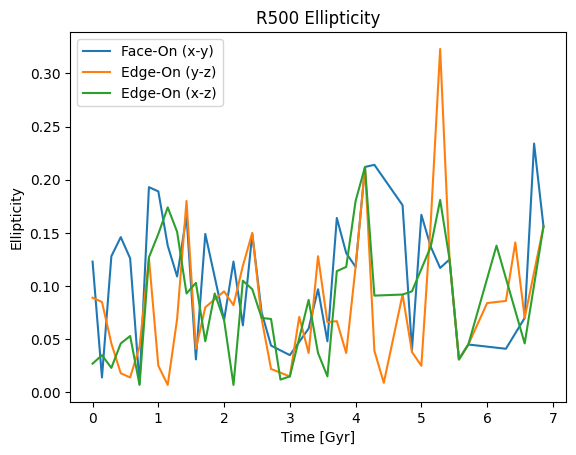

In [32]:
# Plot ellipticity for R500, R500/2, and R500/4 over time
j = 3

plt.plot(Halo_01[:,0]/1000, Halo_01[:,j], label=r'Face-On (x-y)')
plt.plot(Halo_12[:,0]/1000, Halo_12[:,j], label=r'Edge-On (y-z)')
plt.plot(Halo_02[:,0]/1000, Halo_02[:,j], label=r'Edge-On (x-z)')

plt.xlabel('Time [Gyr]')
plt.ylabel('Ellipticity')

plt.title('R500 Ellipticity')

plt.legend()

#plt.savefig('Ellipticity_Evolution_02.png')

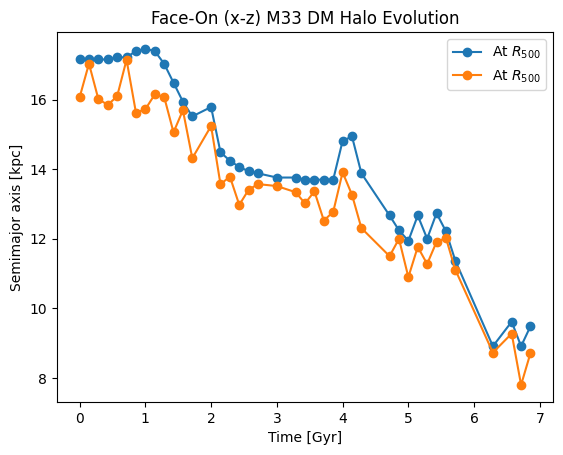

In [42]:
plt.plot(Halo_01[:,0]/1000, Halo_01[:,9], label=r'At $R_{500}$', marker='o')
plt.plot(Halo_01[:,0]/1000, Halo_01[:,12], label=r'At $R_{500}$', marker='o')
# plt.plot(Halo_02[:,0]/1000, Halo_02[:,9], label=r'At $R_{500}$', marker='o')
# plt.plot(Halo_12[:,0]/1000, Halo_12[:,9], label=r'At $R_{500}$', marker='o')

#plt.plot(Halo_02[:,0]/1000, Halo_02[:,2], label=r'At $R_{500}/2$', marker='o')
#plt.plot(Halo_02[:,0]/1000, Halo_02[:,3], label=r'At $R_{500}/4$', marker='o')

plt.xlabel('Time [Gyr]')
plt.ylabel('Semimajor axis [kpc]')

plt.title('Face-On (x-z) M33 DM Halo Evolution')

plt.legend()

#plt.savefig('Ellipticity_Evolution_02.png')